<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/bionomial_distribution_without_scipy_module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
''' bionomial distribution without using numoy and scipy module'''

import math
import numpy as np
import matplotlib.pyplot as plt

def comb_nCk(N,K):
  M = N-K
  combination = math.factorial(N)/(math.factorial(M)*math.factorial(K))
  return combination


# bionm of p(k) = c(n,k)*p^k*(1-p)^(n-k)
# check number_of_sucess is list or integer
def binomial_pmf(trails,probability,number_of_sucess):
  probability_of_success = []
  if isinstance(number_of_sucess,int):
    combination = comb_nCk(trails,number_of_sucess)
    prob_for_each_success = combination*(probability**number_of_sucess)*(1-probability)**(trails-number_of_sucess)
    return prob_for_each_success
  else:
    for each_success in number_of_sucess:
      combination = comb_nCk(trails,each_success)
      prob_for_each_success = combination*(probability**each_success)*(1-probability)**(trails-each_success)
      probability_of_success.append(prob_for_each_success)
    return probability_of_success

def binomial_cdf(n1,p1,k1):
  cdf = []
  if isinstance(k1, int):
    k = [j for j in range(k1+1)]
    pmf = binomial_pmf(n1,p1,k)
  else :
    pmf = binomial_pmf(n1,p1,k1)
  indv_pmf = 0
  for i in pmf:
    indv_pmf += i
    cdf.append(indv_pmf)
  return cdf

In [27]:
# entropy is how much information we gain from uncertainty. more uncertain more information gain, more accurate result means less information gain
# information gain = -log2p(x); log base 2 called bit.
# entropy = -sum(0,n) of p(x)*logp(x); natural log unit called nats,
def cal_entropy(n2,p2,k2):
  if isinstance(k2, int):
    pmf = binomial_pmf(n2,p2,k2)
    info = -math.log2(pmf)
    entropy = pmf*info
    return entropy,info
  else:
    pmf_list = binomial_pmf(n2,p2,k2)
    info_list = [-math.log2(i) for i in pmf_list]
    entropy_list = [pmf_list[i]*info_list[i] for i in range(len(pmf_list))]
    avg_entropy = sum(entropy_list)
    return info_list,avg_entropy

In [28]:
n = 20 # number of trails
k = np.arange(1,20).tolist() # number of success
# k = [1,2,3,4,5]
p = 0.5


# probability mass function
pmf = binomial_pmf(n,p,k)
# cumulative distribution function
cdf = binomial_cdf(n,p,k)
# entropy
information_gain = cal_entropy(n,p,k)

# print output
print(f'information gain :{np.array(information_gain[0])}')
print(f'average entropy :{information_gain[1]}')
print(f'cumulative distribution function :{np.array(cdf)}')
print(f'binomial pmf :{np.array(pmf)}')

information gain :[15.67807191 12.43014439  9.84518189  7.75771905  6.07964714  4.75771905
  3.75771905  3.05727933  2.64224183  2.50473831  2.64224183  3.05727933
  3.75771905  4.75771905  6.07964714  7.75771905  9.84518189 12.43014439
 15.67807191]
average entropy :3.2076845101607296
cumulative distribution function :[1.90734863e-05 2.00271606e-04 1.28746033e-03 5.90801239e-03
 2.06937790e-02 5.76581955e-02 1.31587029e-01 2.51721382e-01
 4.11900520e-01 5.88097572e-01 7.48276711e-01 8.68411064e-01
 9.42339897e-01 9.79304314e-01 9.94090080e-01 9.98710632e-01
 9.99797821e-01 9.99979019e-01 9.99998093e-01]
binomial pmf :[1.90734863e-05 1.81198120e-04 1.08718872e-03 4.62055206e-03
 1.47857666e-02 3.69644165e-02 7.39288330e-02 1.20134354e-01
 1.60179138e-01 1.76197052e-01 1.60179138e-01 1.20134354e-01
 7.39288330e-02 3.69644165e-02 1.47857666e-02 4.62055206e-03
 1.08718872e-03 1.81198120e-04 1.90734863e-05]


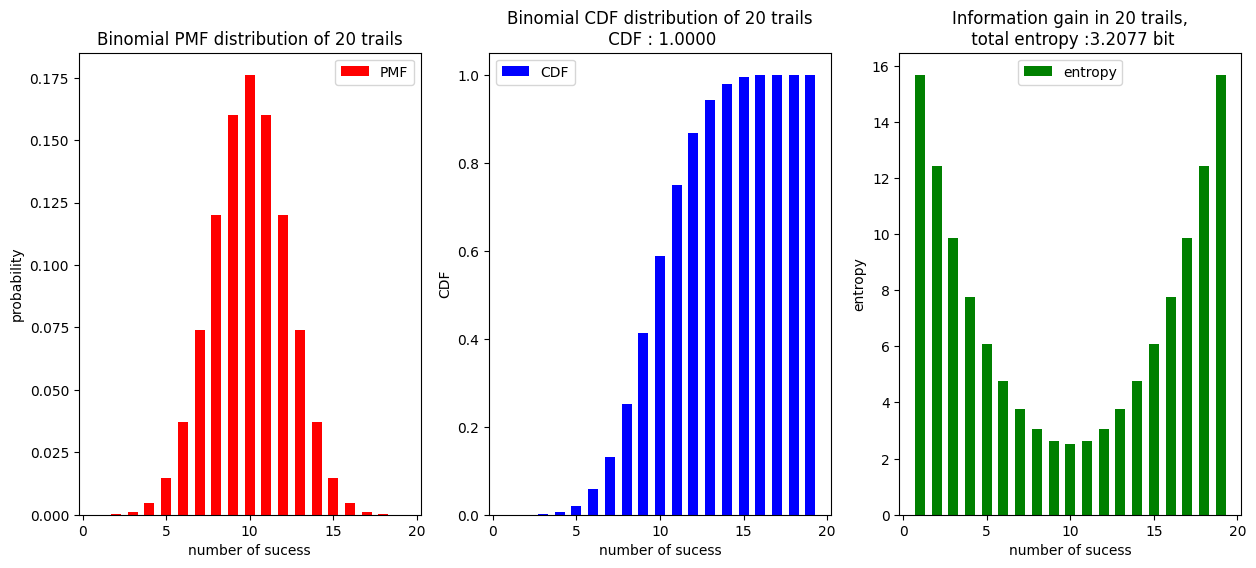

In [29]:

# visualize this
w = 0.6
fig, axes = plt.subplots(1,3,figsize = (15,6)) # 1 row and 3 column

axes[0].bar(k,pmf,width = w,color = 'red',label = 'PMF')
axes[0].set_xlabel('number of sucess')
axes[0].set_ylabel('probability')
axes[0].set_title(f'Binomial PMF distribution of {n} trails')
axes[0].legend()

if isinstance(k, int):
  axes[1].bar(range(k+1),cdf,width = w,color = 'blue',label = 'CDF')
else :
  axes[1].bar(k,cdf,width = w,color = 'blue')
axes[1].bar(k,cdf,width = w,color = 'blue',label = 'CDF')
axes[1].set_xlabel('number of sucess')
axes[1].set_ylabel('CDF')
axes[1].set_title(f'Binomial CDF distribution of {n} trails\n CDF : {cdf[-1]:.4f}')
axes[1].legend()


axes[2].bar(k,information_gain[0],width = w,color = 'green',label = 'entropy')
axes[2].set_xlabel('number of sucess')
axes[2].set_ylabel('entropy')
axes[2].set_title(f'Information gain in {n} trails,\n total entropy :{information_gain[1]:.4f} bit')
axes[2].legend()
plt.show()